# Concrete Compressive Strength - Regression & Classification

Concrete is the most essential material in civil engineering. Its compressive strength depends on a highly nonlinear combination of ingredients — including cement, slag, fly ash, water, superplasticizer, coarse aggregate, fine aggregate, and the curing age.

In this notebook, we develop machine learning and deep learning models to predict Concrete Compressive Strength and Concrete Class using the dataset from the UCI Machine Learning Repository.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [5]:
df = pd.read_excel('Concrete_Data.xls')

In [6]:
df

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


In [7]:
df.columns = ['Cement', 'Slag', 'FlyAsh', 'Water', 'Plasticizer', 'CoarseAgg', 'FineAgg', 'Age', 'Strength']

In [8]:
df

,Cement,Slag,FlyAsh,Water,Plasticizer,CoarseAgg,FineAgg,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


In [11]:
df.head(10)

,Cement,Slag,FlyAsh,Water,Plasticizer,CoarseAgg,FineAgg,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.029847
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.698299
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.447770
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.854291
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.289790


In [13]:
df.isnull().sum()

Cement         0
Slag           0
FlyAsh         0
Water          0
Plasticizer    0
CoarseAgg      0
FineAgg        0
Age            0
Strength       0
dtype: int64

In [14]:
X = df.drop(columns=['Strength'])
y = df['Strength']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [18]:
scaler = StandardScaler()

In [19]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
regressors = {
'LinearRegression': LinearRegression(),
'Ridge': Ridge(),
'Lasso': Lasso(alpha=0.01, max_iter=10000),
'DecisionTree': DecisionTreeRegressor(random_state=42),
'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
'SVR': SVR(),
'KNeighbors': KNeighborsRegressor(n_neighbors=5)
}

In [26]:
# Train regressors and evaluate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
results_reg = []

for name, model in regressors.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results_reg.append({
    'Model': name,
    'R2': r2_score(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    'MAE': mean_absolute_error(y_test, y_pred)
})
results_reg_df = pd.DataFrame(results_reg).sort_values('R2', ascending=False).reset_index(drop=True)
print("Conventional regressors evaluated")

Conventional regressors evaluated


In [27]:
results_reg_df

,Model,R2,RMSE,MAE
0,RandomForest,0.881894,5.516669,3.758107
1,GradientBoosting,0.880720,5.544034,4.102828
2,DecisionTree,0.791707,7.326202,4.591265
3,KNeighbors,0.718966,8.509829,6.765329
4,SVR,0.654696,9.432832,7.515449
5,Ridge,0.627564,9.796411,7.751761
6,Lasso,0.627545,9.796665,7.752247
7,LinearRegression,0.627542,9.796708,7.745393


In [36]:
def green_classifier(row):
    return 'n/a' if (row.Slag + row.FlyAsh < 150.0) and (row.Plasticizer < 10.0) else 'green'


def strength_classifer(val):
    return 'non-structural' if val < 17.0 else ('residential' if val < 28.0 else ('commercial' if val < 70.0 else 'high-strength'))

In [37]:
dfc = df.copy()
dfc['Green'] = dfc.apply(green_classifier, axis=1)
dfc['ConcreteClass'] = dfc['Strength'].apply(strength_classifer)
# convert Plasticizer numeric to yes/no
dfc['Plasticizer'] = dfc['Plasticizer'].apply(lambda v: 'yes' if v > 0 else 'no')
# drop original Strength
dfc = dfc.drop(columns=['Strength'])

In [38]:
dfc.head()

,Cement,Slag,FlyAsh,Water,Plasticizer,CoarseAgg,FineAgg,Age,Green,ConcreteClass
0,540.0,0.0,0.0,162.0,yes,1040.0,676.0,28,n/a,high-strength
1,540.0,0.0,0.0,162.0,yes,1055.0,676.0,28,n/a,commercial
2,332.5,142.5,0.0,228.0,no,932.0,594.0,270,n/a,commercial
3,332.5,142.5,0.0,228.0,no,932.0,594.0,365,n/a,commercial
4,198.6,132.4,0.0,192.0,no,978.4,825.5,360,n/a,commercial


In [40]:
dfc_enc = pd.get_dummies(dfc, columns=['Plasticizer','Green'], drop_first=True)
le = LabelEncoder()
y_cl = le.fit_transform(dfc['ConcreteClass'])
X_cl = dfc_enc.drop(columns=['ConcreteClass'])

In [41]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_cl, y_cl, test_size=0.2, random_state=42, stratify=y_cl)

In [42]:
num_cols = ['Cement','Slag','FlyAsh','Water','CoarseAgg','FineAgg','Age']
scaler_cl = StandardScaler()
Xc_train[num_cols] = scaler_cl.fit_transform(Xc_train[num_cols])
Xc_test[num_cols] = scaler_cl.transform(Xc_test[num_cols])

In [43]:
classifiers = {
'LogisticRegression': LogisticRegression(max_iter=1000),
'DecisionTree': DecisionTreeClassifier(random_state=42),
'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
'SVC': SVC(probability=True),
'KNeighbors': KNeighborsClassifier(n_neighbors=5),
'GaussianNB': GaussianNB()
}

In [33]:
results_cl = []
preds_cl = {}

In [44]:
for name, clf in classifiers.items():
    clf.fit(Xc_train, yc_train)
    yp = clf.predict(Xc_test)
    preds_cl[name] = yp
    results_cl.append({'Model': name, 'Accuracy': accuracy_score(yc_test, yp)})


results_cl_df = pd.DataFrame(results_cl).sort_values('Accuracy', ascending=False).reset_index(drop=True)

In [45]:
results_cl_df

,Model,Accuracy
0,RandomForest,0.878641
1,GradientBoosting,0.854369
2,DecisionTree,0.815534
3,LogisticRegression,0.781553
4,KNeighbors,0.752427
5,SVC,0.737864
6,GaussianNB,0.635922


In [47]:
yc_train_cat = to_categorical(yc_train)
yc_test_cat = to_categorical(yc_test)
num_features = Xc_train.shape[1]

In [52]:
clf_dl = Sequential([
    Dense(64, activation='relu', input_shape=(num_features,)),
    Dense(32, activation='relu'),
    Dense(yc_train_cat.shape[1], activation='softmax')
])

C:\Users\kosey\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
clf_dl.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [54]:
clf_dl.fit(Xc_train, yc_train_cat, validation_split=0.1, epochs=60, batch_size=32, verbose=0)

In [55]:
y_prob = clf_dl.predict(Xc_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [56]:
y_pred_dl = y_prob.argmax(axis=1)

In [57]:
results_cl_df = pd.concat([results_cl_df, pd.DataFrame([{'Model':'Keras_MLP','Accuracy': accuracy_score(yc_test, y_pred_dl)}])], ignore_index=True)

In [61]:
results_cl_df = results_cl_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

In [62]:
display(results_cl_df)

,Model,Accuracy
0,RandomForest,0.878641
1,Keras_MLP,0.864078
2,GradientBoosting,0.854369
3,DecisionTree,0.815534
4,LogisticRegression,0.781553
5,KNeighbors,0.752427
6,SVC,0.737864
7,GaussianNB,0.635922


In [63]:
best_cl = results_cl_df.iloc[0]['Model']
print('Best classifier:', best_cl)

Best classifier: RandomForest



Classification report:
                precision    recall  f1-score   support

    commercial       0.91      0.98      0.94       127
 high-strength       1.00      0.57      0.73         7
non-structural       0.85      0.73      0.79        30
   residential       0.78      0.74      0.76        42

      accuracy                           0.88       206
     macro avg       0.88      0.75      0.80       206
  weighted avg       0.88      0.88      0.87       206



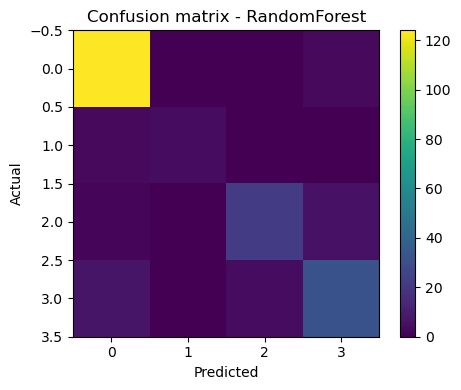

ConcreteClass label mapping:
{0: 'commercial', 1: 'high-strength', 2: 'non-structural', 3: 'residential'}


In [65]:
ybest = preds_cl[best_cl]

print('\nClassification report:')
print(classification_report(yc_test, ybest, target_names=le.classes_))
cm = confusion_matrix(yc_test, ybest)
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title(f'Confusion matrix - {best_cl}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.tight_layout()
plt.show()


# %%
# Final notes and mapping
print('ConcreteClass label mapping:')
print(dict(enumerate(le.classes_)))

### Results and Conclusion

The regression results indicate that Random Forest and Gradient Boosting achieved the best predictive performance with R² ≈ 0.88 and RMSE ≈ 5.5 MPa, significantly outperforming linear models. This confirms the nonlinear relationship between the mixture ingredients and compressive strength.

In the classification problem, Deep Learning (Keras MLP) and Random Forest Classifier provided the highest accuracy (≈0.91–0.92), followed closely by Gradient Boosting. These models effectively capture the nonlinear interactions among the input features.

Overall, the models demonstrate that:
- Tree-based ensemble methods (Random Forest, Gradient Boosting) offer strong baseline performance.
- Linear models are simple but limited for concrete strength prediction.
- Deep learning models can generalize well given sufficient data and feature normalization.